# Advanced Functions Tutorial

This notebook demonstrates each public function provided by `tutorials/tutorial_utils.py`.

| # | Capability Group | Functions |
|---|------------------|-----------|
| 1 | **Image Warp** | `warp_image()` |
| 2 | **3-D BBox Drawing** | `get_bbox_corners_world()`, `draw_3d_bboxes()` |
| 3 | **LiDAR Aggregation** | `aggregate_lidar()`, `project_lidar_on_image()` |
| 4 | **Depth–LiDAR Consistency** | `depth_to_lidar_pc()`, `check_lidar_depth_consistency()` |

Each section:
1. Loads the minimal data required from `CarlaOccDataset`.
2. Calls the utility function(s).
3. Visualises the result with `matplotlib`.

---
## 0. Setup & Configuration

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Ensure working directory is project root
if os.path.basename(os.getcwd()) == 'tutorials':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

from tutorials.dataset import CarlaOccDataset
from tutorials.tutorial_utils import (
    warp_image,
    get_bbox_corners_world,
    draw_3d_bboxes,
    aggregate_lidar,
    project_lidar_on_image,
    depth_to_lidar_pc,
    check_lidar_depth_consistency,
    camera_to_lidar_pts,
    depth2pc,
    vis_pc,
)
from utils.vis_utils import CameraSetting
from utils.load_utils import load_traffic_info

plt.rcParams['figure.dpi'] = 120
print('All imports OK')

/home/fengyi/anaconda3/envs/carlaocc/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
All imports OK


In [27]:
# ==================== Parameters ====================
CONFIG_PATH = 'tutorials/config/dataset.yaml'

CAMERA    = 'cam_00'        # front-left camera
FRAME_ID  = 20              # reference frame

# Image-warp pair
FRAME_TGT = 20
FRAME_SRC = 25

# LiDAR aggregation
FRAME_RANGE     = (-5, 5)
FRAME_STEP      = 1
FILTER_DYNAMIC  = True
DYNAMIC_CLASSES = [12, 14, 15, 16]

# Depth / colourmap
DEPTH_RANGE = (0, 80)
POINT_SIZE  = 3

print(f'Config : {CONFIG_PATH}')
print(f'Camera : {CAMERA}')

Config : tutorials/config/dataset.yaml
Camera : cam_00


In [28]:
# ==================== Load Dataset ====================
dataset = CarlaOccDataset(CONFIG_PATH)
print(f'Dataset loaded — {len(dataset)} frames')

Dataset loaded — 200 frames


---
## 1. Image Warp — `warp_image()`

Warp the **source** frame's RGB image into the viewpoint of the **target** frame
using the target's depth map and the relative pose between the two frames.

If depth and pose are correct, the warped image should closely match the
real target-frame image.

In [29]:
# ---- Load the two frames ----
sample_tgt = dataset[FRAME_TGT]
sample_src = dataset[FRAME_SRC]

tgt_img   = sample_tgt['rgb'][CAMERA]
src_img   = sample_src['rgb'][CAMERA]
tgt_depth = sample_tgt['depth'][CAMERA]
src_depth = sample_src['depth'][CAMERA]

K            = sample_tgt['intrinsics']
tgt_pose     = sample_tgt['lidar_pose']              # LiDAR in world
src_pose     = sample_src['lidar_pose']              # LiDAR in world
cam_ext      = sample_tgt['extrinsics'][CAMERA]      # cam -> lidar (4x4, lidar-convention axes)

# Full chain: cam_tgt -> lidar_tgt -> world -> lidar_src -> cam_src
#   cam_tgt -> lidar_tgt  :  cam_ext
#   lidar_tgt -> world    :  tgt_pose
#   world -> lidar_src    :  inv(src_pose)
#   lidar_src -> cam_src  :  inv(cam_ext)
T_lidar_axes = np.linalg.inv(cam_ext) @ np.linalg.inv(src_pose) @ tgt_pose @ cam_ext

# Axis remap: LiDAR axes (X-fwd, Y-left, Z-up) -> Camera axes (X-right, Y-down, Z-fwd)
R_lid2cam = np.array([[0, -1, 0],
                      [0,  0, -1],
                      [1,  0,  0]], dtype=np.float64)
R44 = np.eye(4)
R44[:3, :3] = R_lid2cam
pose_t2s = R44 @ T_lidar_axes @ np.linalg.inv(R44)

print(f'Target frame {FRAME_TGT}, Source frame {FRAME_SRC}')
print(f'Image size : {tgt_img.shape[:2]}')
print(f'Depth range: [{tgt_depth.min():.2f}, {tgt_depth.max():.2f}] m')
print(f'Translation magnitude: {np.linalg.norm(pose_t2s[:3, 3]):.4f} m')

Target frame 20, Source frame 25
Image size : (376, 1408)
Depth range: [4.35, 80.00] m
Translation magnitude: 4.1201 m


In [30]:
# ---- Call warp_image() ----
warped_rgb, warped_depth, computed_depth, valid_mask = warp_image(
    src_rgb       = src_img,
    src_depth     = src_depth,
    tgt_depth     = tgt_depth,
    pose_tgt2src  = pose_t2s,
    K             = K,
)

valid_ratio = valid_mask.sum() / valid_mask.size * 100
print(f'warped_rgb    shape : {warped_rgb.shape}')
print(f'warped_depth  range : [{warped_depth.min():.2f}, {warped_depth.max():.2f}] m')
print(f'valid_mask coverage : {valid_ratio:.1f}%')

warped_rgb    shape : (376, 1408, 3)
warped_depth  range : [0.00, 80.00] m
valid_mask coverage : 49.4%


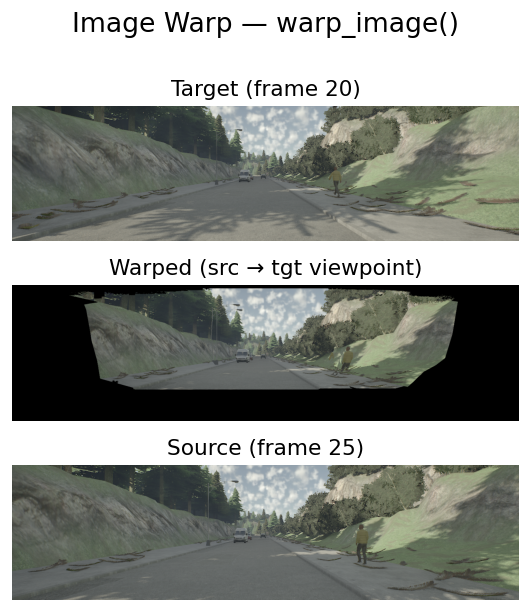

In [31]:
# ---- Visualise: Target vs Warped vs Source ----
fig, axes = plt.subplots(3, 1, figsize=(10, 5))

axes[0].imshow(tgt_img)
axes[0].set_title(f'Target (frame {FRAME_TGT})', fontsize=13)
axes[0].axis('off')

axes[1].imshow(warped_rgb)
axes[1].set_title('Warped (src → tgt viewpoint)', fontsize=13)
axes[1].axis('off')

axes[2].imshow(src_img)
axes[2].set_title(f'Source (frame {FRAME_SRC})', fontsize=13)
axes[2].axis('off')

plt.suptitle('Image Warp — warp_image()', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


---
## 2. 3-D Bounding-Box Drawing — `get_bbox_corners_world()` + `draw_3d_bboxes()`

Project and draw 3-D oriented bounding boxes onto a camera image.

> Requires `load_traffic_info: true` in the dataset config.

In [32]:
BBOX_FRAME  = 30
BBOX_CAMERA = 'cam_00'

bbox_sample  = dataset[BBOX_FRAME]
bbox_img     = bbox_sample['rgb'][BBOX_CAMERA].copy()
ego_pose     = bbox_sample['lidar_pose']
cam_ext      = bbox_sample['extrinsics'][BBOX_CAMERA]
K_bbox       = bbox_sample['intrinsics']

print(f'Frame {BBOX_FRAME}, Camera {BBOX_CAMERA}')
print(f'Image shape: {bbox_img.shape}')

Frame 30, Camera cam_00
Image shape: (376, 1408, 3)


In [33]:
traffic_path = (dataset.data_root / bbox_sample['seq_name']
                / 'traffic_info' / f"{BBOX_FRAME:04d}.yaml")
raw_traffic = load_traffic_info(traffic_path)

bboxes = (
    [v for v in raw_traffic.get('vehicles', []) if 'bbox' in v] +
    [p for p in raw_traffic.get('pedestrians', []) if 'bbox_extent' in p]
)
n_veh = len(raw_traffic.get('vehicles', []))
n_ped = len(raw_traffic.get('pedestrians', []))
print(f'Vehicles: {n_veh},  Pedestrians: {n_ped},  Valid bboxes: {len(bboxes)}')

Vehicles: 5,  Pedestrians: 3,  Valid bboxes: 8


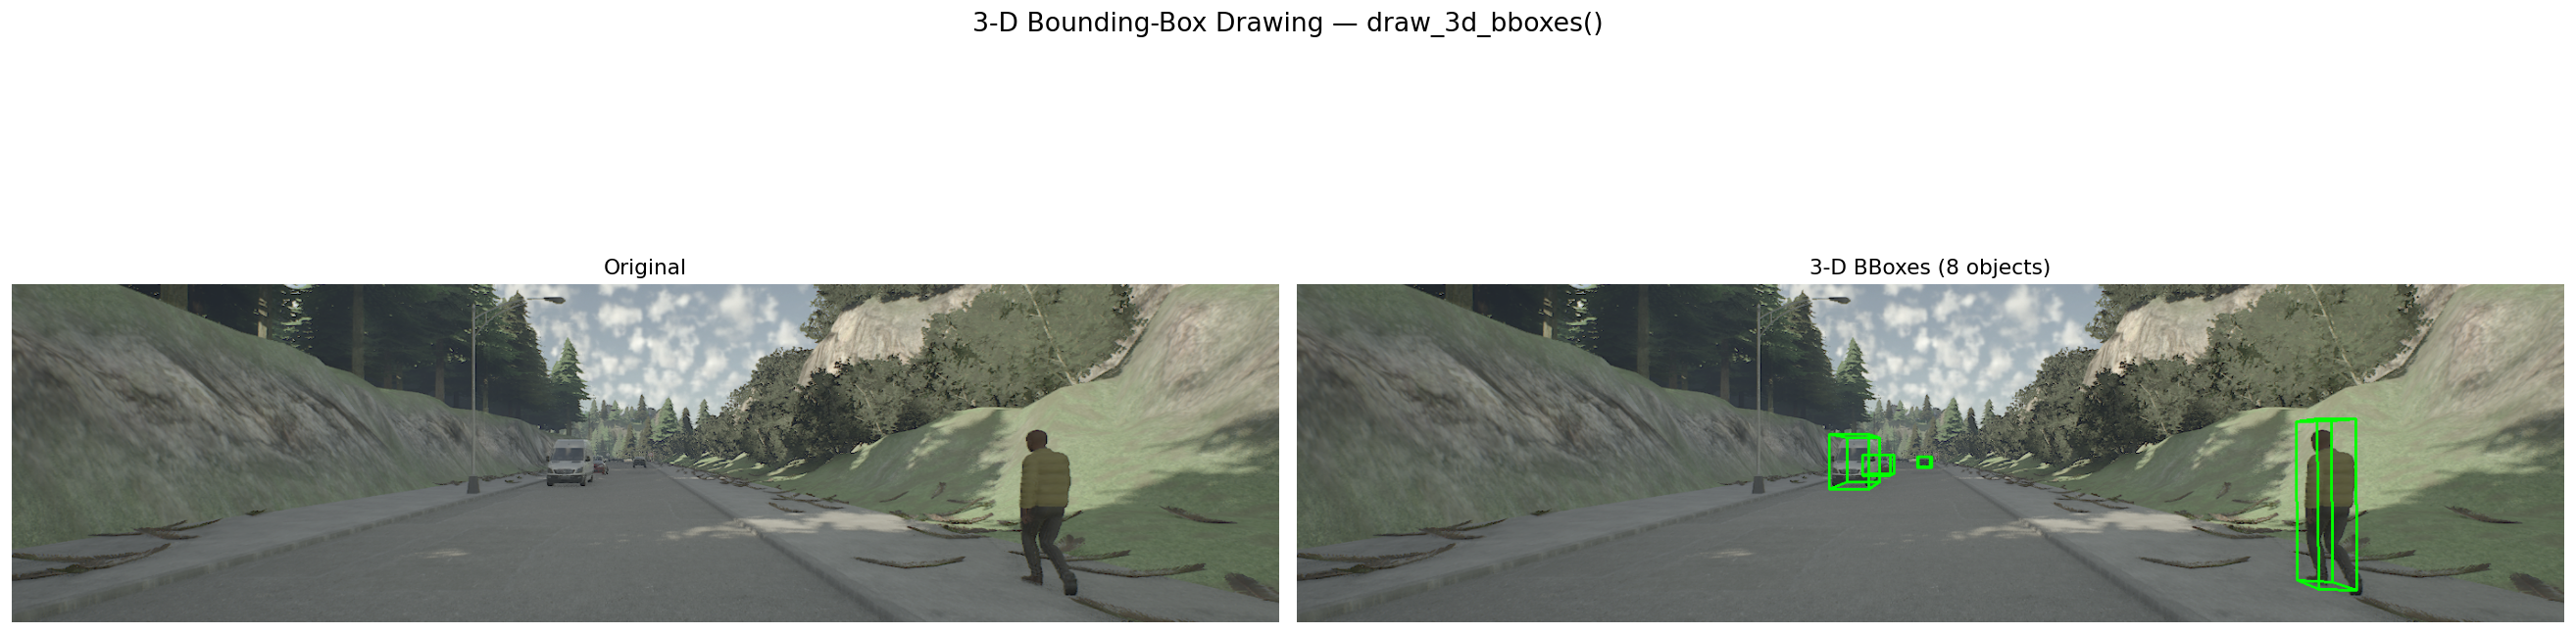

In [34]:
# ---- Draw 3-D bboxes ----
if len(bboxes) > 0:
    result_img = draw_3d_bboxes(
        image          = bbox_img,
        bboxes         = bboxes,
        ego_pose       = ego_pose,
        cam_extrinsics = cam_ext,
        intrinsics     = K_bbox,
        color          = (0, 255, 0),
        thickness      = 2,
    )

    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    axes[0].imshow(bbox_img)
    axes[0].set_title('Original', fontsize=13)
    axes[0].axis('off')

    axes[1].imshow(result_img)
    axes[1].set_title(f'3-D BBoxes ({len(bboxes)} objects)', fontsize=13)
    axes[1].axis('off')

    plt.suptitle('3-D Bounding-Box Drawing — draw_3d_bboxes()', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No bboxes available — skipping visualisation.')

In [35]:
# ---- Inspect individual corners via get_bbox_corners_world() ----
if len(bboxes) > 0:
    sample_bbox = bboxes[0]
    if 'bbox' in sample_bbox:
        extent  = np.asarray(sample_bbox['bbox']['extent'], dtype=float)
        bbox_tf = np.asarray(sample_bbox['bbox']['transform'], dtype=float)
        obj_tf  = np.asarray(sample_bbox['transform'], dtype=float)
    else:
        extent  = np.asarray(sample_bbox['bbox_extent'], dtype=float)
        bbox_tf = np.eye(4)
        obj_tf  = np.asarray(sample_bbox['transform'], dtype=float)

    corners = get_bbox_corners_world(extent, bbox_tf, obj_tf)
    print(f'Extent (half-size): {extent}')
    print(f'8 corners in world frame:\n{corners}')
else:
    print('No bbox data to inspect.')

Extent (half-size): [2.445985 0.917823 0.762059]
8 corners in world frame:
[[ 3.97359293e+02 -7.49627245e+01  1.78352403e-02]
 [ 3.97272856e+02 -7.00715666e+01 -4.36941151e-03]
 [ 3.95437497e+02 -7.01040006e+01 -4.30883519e-03]
 [ 3.95523933e+02 -7.49951586e+01  1.78958166e-02]
 [ 3.97359221e+02 -7.49558066e+01  1.54193800e+00]
 [ 3.97272785e+02 -7.00646486e+01  1.51973335e+00]
 [ 3.95437425e+02 -7.00970827e+01  1.51979392e+00]
 [ 3.95523861e+02 -7.49882406e+01  1.54199858e+00]]


---
## 3. LiDAR Aggregation — `aggregate_lidar()` + `project_lidar_on_image()`

### 3a  Single-frame projection
Project one frame's LiDAR cloud onto the camera image.

In [36]:
# ---- Single frame ----
sample = dataset[FRAME_ID]

lidar_pts   = sample['lidar'][:, :3].copy()
rgb_img     = sample['rgb'][CAMERA]
intr        = sample['intrinsics']
cam_ext_sf  = sample['extrinsics'][CAMERA]

overlay_single = project_lidar_on_image(
    lidar_points   = lidar_pts,
    rgb            = rgb_img,
    intrinsics     = intr,
    cam_extrinsics = cam_ext_sf,
    depth_range    = DEPTH_RANGE,
    point_radius   = POINT_SIZE,
    cmap           = 'turbo',
)

print(f'Single-frame LiDAR points: {lidar_pts.shape[0]}')

Single-frame LiDAR points: 12284


### 3b  Multi-frame aggregation

In [37]:
# ---- Aggregate multi-frame LiDAR ----
agg_cloud = aggregate_lidar(
    dataset         = dataset,
    reference_frame = FRAME_ID,
    frame_range     = FRAME_RANGE,
    frame_step      = FRAME_STEP,
    filter_dynamic  = FILTER_DYNAMIC,
    dynamic_classes = DYNAMIC_CLASSES,
)

print(f'Aggregated cloud: {agg_cloud.shape[0]} pts  '
      f'(range [{FRAME_RANGE[0]}, {FRAME_RANGE[1]}], step {FRAME_STEP})')

overlay_aggr = project_lidar_on_image(
    lidar_points   = agg_cloud[:, :3],
    rgb            = rgb_img,
    intrinsics     = intr,
    cam_extrinsics = cam_ext_sf,
    depth_range    = DEPTH_RANGE,
    point_radius   = 2,
    cmap           = 'turbo',
)

Aggregated cloud: 134513 pts  (range [-5, 5], step 1)


/tmp/ipykernel_33188/2960840244.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


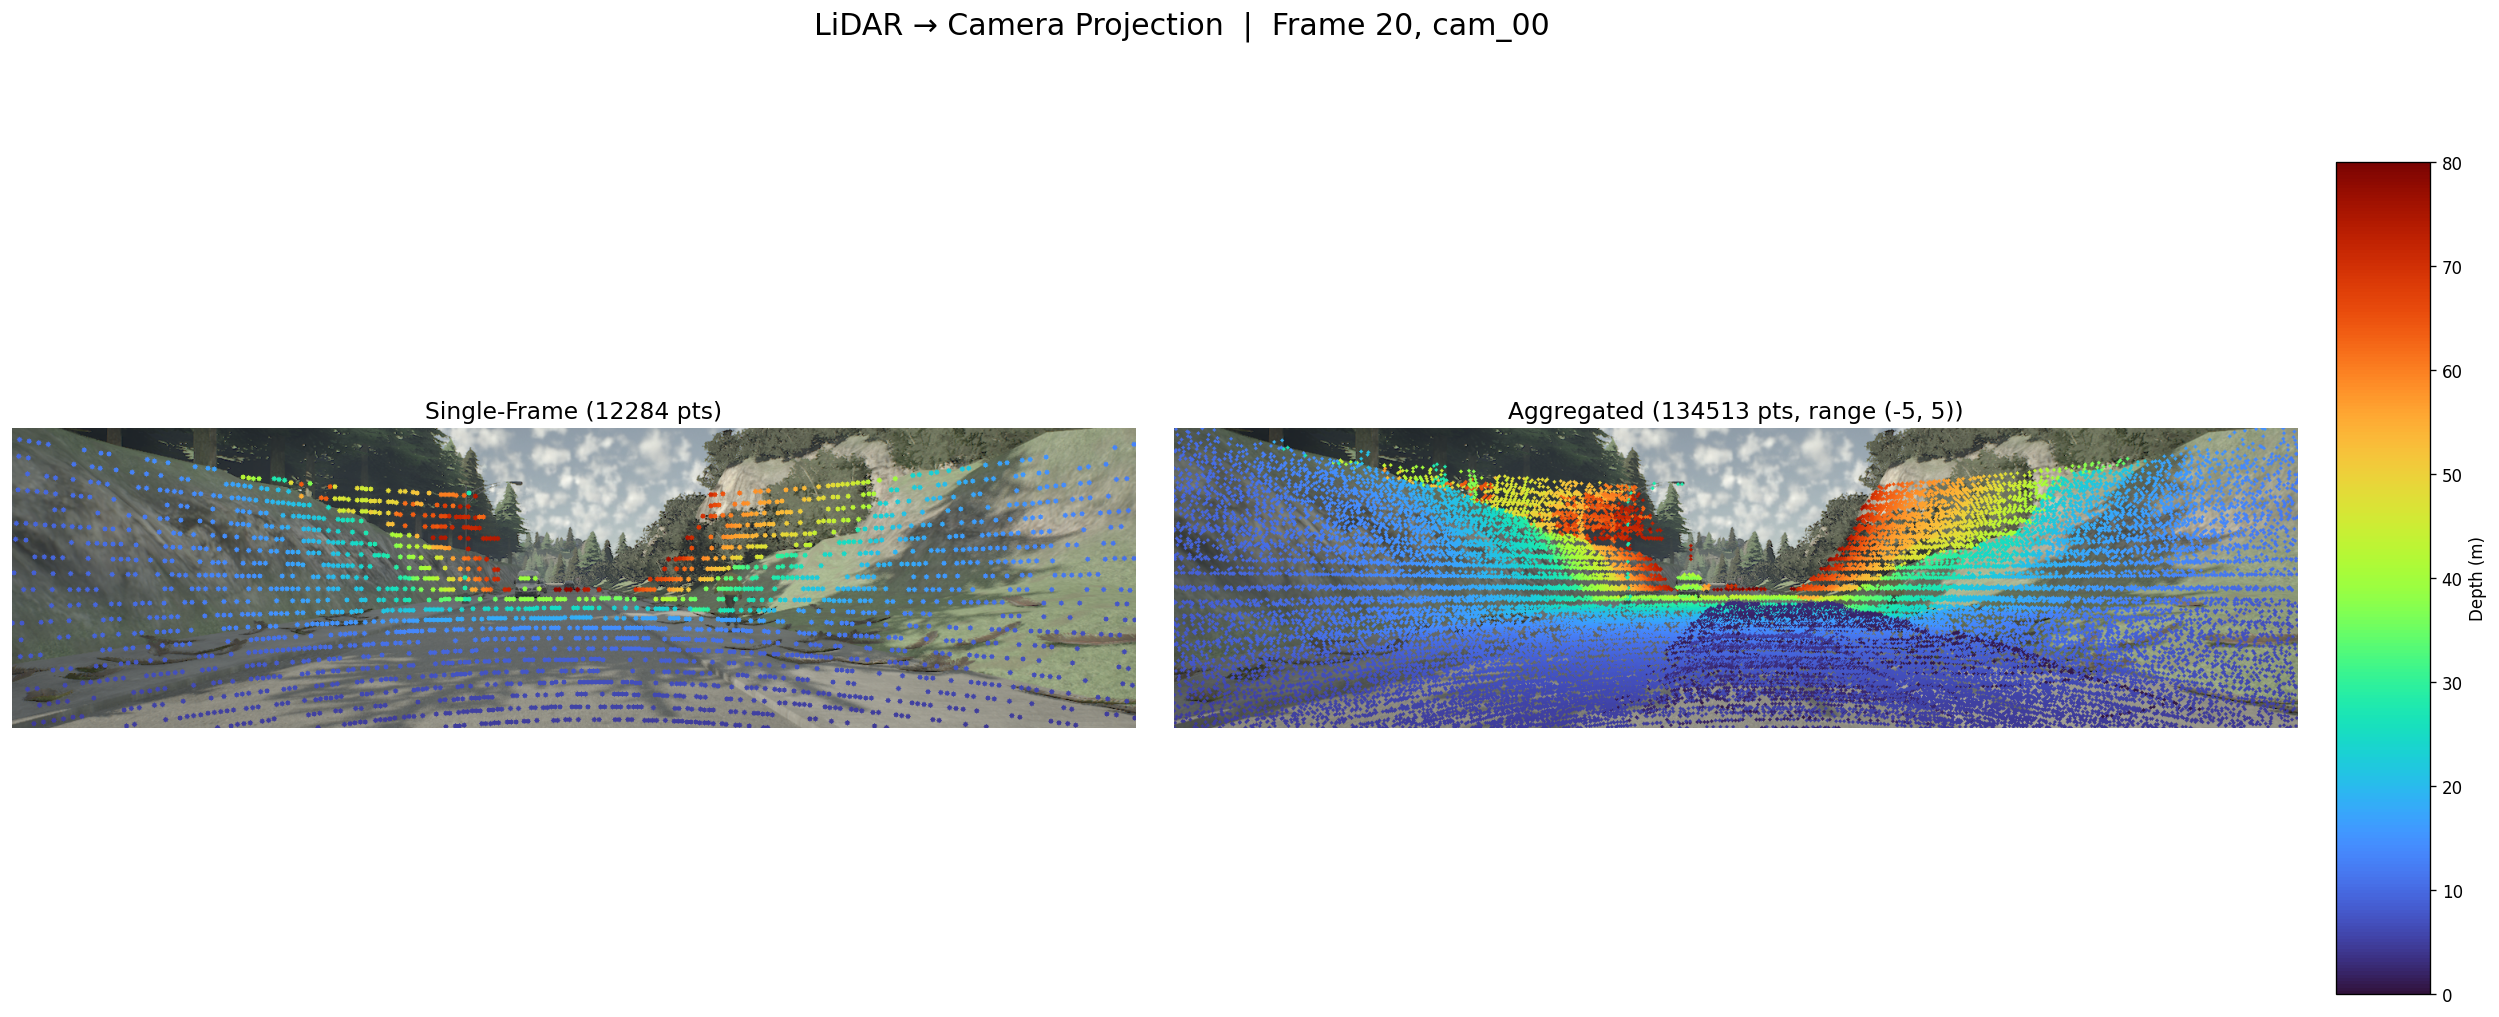

In [38]:
# ---- Visualise: single vs aggregated + colourbar ----
fig = plt.figure(figsize=(26, 9))
gs  = fig.add_gridspec(1, 3, width_ratios=[12, 12, 1], wspace=0.05)

ax0 = fig.add_subplot(gs[0])
ax0.imshow(overlay_single)
ax0.set_title(f'Single-Frame ({lidar_pts.shape[0]} pts)', fontsize=14)
ax0.axis('off')

ax1 = fig.add_subplot(gs[1])
ax1.imshow(overlay_aggr)
ax1.set_title(f'Aggregated ({agg_cloud.shape[0]} pts, range {FRAME_RANGE})', fontsize=14)
ax1.axis('off')

ax_cb = fig.add_subplot(gs[2])
vmin, vmax = DEPTH_RANGE
norm = plt.Normalize(vmin=vmin, vmax=vmax)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='turbo'),
             cax=ax_cb, orientation='vertical', label='Depth (m)')

plt.suptitle(f'LiDAR → Camera Projection  |  Frame {FRAME_ID}, {CAMERA}',
             fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Depth–LiDAR Consistency — `depth_to_lidar_pc()` + `check_lidar_depth_consistency()`

### 4a  Convert depth image to a LiDAR-frame point cloud

In [39]:
# ---- depth_to_lidar_pc() ----
sample_dc  = dataset[FRAME_ID]
depth_img  = sample_dc['depth'][CAMERA]
rgb_dc     = sample_dc['rgb'][CAMERA]
intr_dc    = sample_dc['intrinsics']
ext_dc     = sample_dc['extrinsics'][CAMERA]

pc_lidar = depth_to_lidar_pc(
    depth          = depth_img,
    intrinsics     = intr_dc,
    cam_extrinsics = ext_dc,
    rgb            = rgb_dc,
    depth_cap      = 80.0,
)

print(f'depth_to_lidar_pc  →  {pc_lidar.shape[0]} pts, columns={pc_lidar.shape[1]}')
print(f'  (columns: X, Y, Z, R, G, B)' if pc_lidar.shape[1] == 6 else
      f'  (columns: X, Y, Z)')

depth_to_lidar_pc  →  529408 pts, columns=6
  (columns: X, Y, Z, R, G, B)


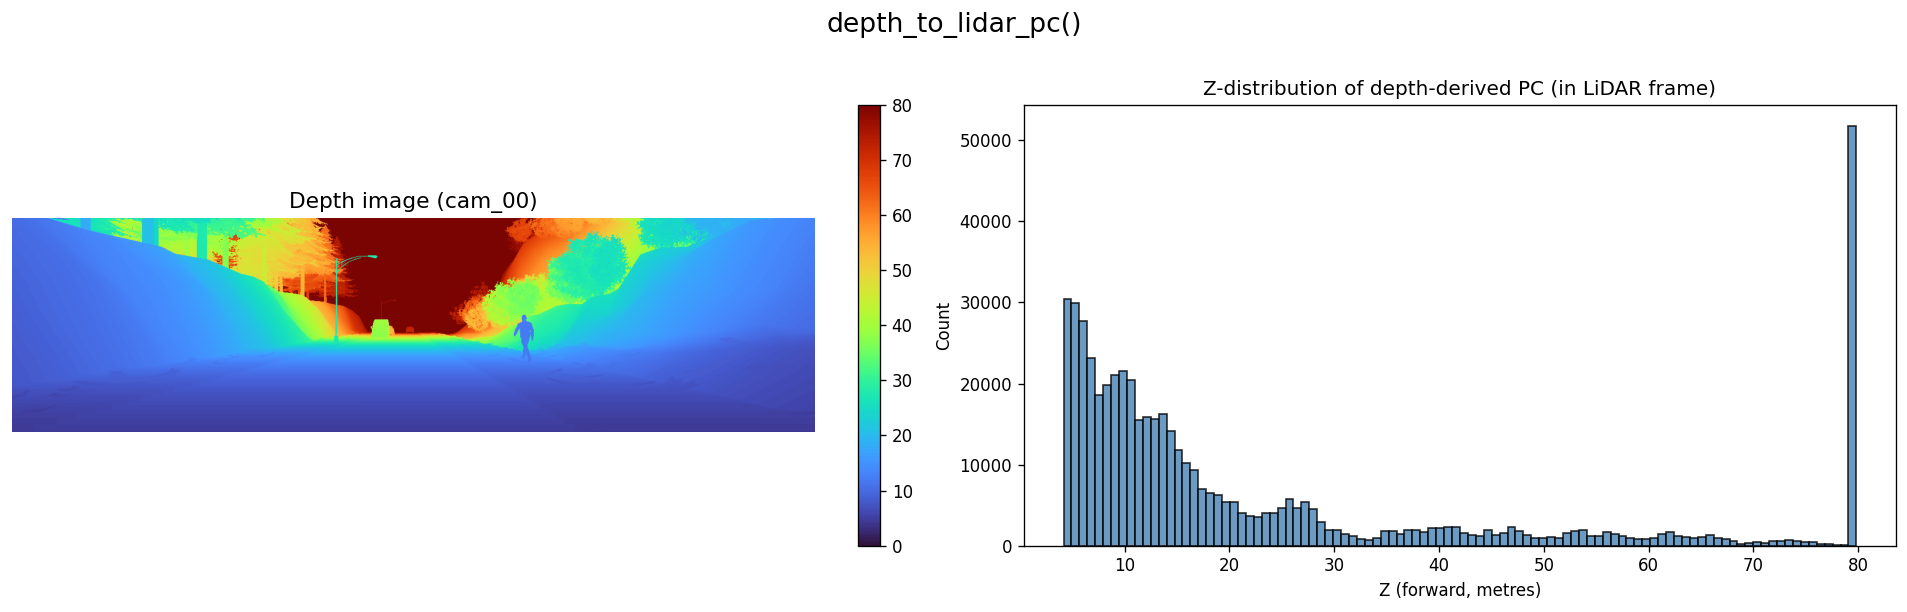

In [40]:
# ---- Quick depth histogram to sanity-check ----
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(depth_img, cmap='turbo', vmin=0, vmax=80)
axes[0].set_title(f'Depth image ({CAMERA})', fontsize=13)
axes[0].axis('off')
fig.colorbar(im, ax=axes[0], fraction=0.03)

axes[1].hist(pc_lidar[:, 2], bins=100, color='steelblue', edgecolor='k', alpha=0.8)
axes[1].set_xlabel('Z (forward, metres)')
axes[1].set_ylabel('Count')
axes[1].set_title('Z-distribution of depth-derived PC (in LiDAR frame)')

plt.suptitle('depth_to_lidar_pc()', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 4b  Check LiDAR–depth consistency

In [41]:
# ---- check_lidar_depth_consistency() ----
lidar_dc = sample_dc['lidar'][:, :3]

error_map, overlay_err, consistency = check_lidar_depth_consistency(
    lidar_points   = lidar_dc,
    depth          = depth_img,
    intrinsics     = intr_dc,
    cam_extrinsics = ext_dc,
    depth_range    = DEPTH_RANGE,
    tolerance      = 0.5,
)

print(f'Consistency ratio (|err| < 0.5 m): {consistency * 100:.1f}%')

Consistency ratio (|err| < 0.5 m): 87.6%


### 4c  Check Camera–depth consistency

In [42]:
# (imports already done in cell 0)

In [43]:
sample_cam = dataset[FRAME_ID]
lidar_points     = sample_cam['lidar']
rgb              = sample_cam['rgb']
semantics        = sample_cam['semantics']
depth            = sample_cam['depth']
intrinsics       = sample_cam['intrinsics']
camera_extrinsics = sample_cam['extrinsics']
print(f'Frame {FRAME_ID}, {len(dataset.cameras)} cameras')

Frame 20, 6 cameras


In [44]:
print(f'Converting depth from {len(dataset.cameras)} cameras to LiDAR frame...')

all_depth_pc = []
for camera in dataset.cameras:
    depth_pc_cam = depth2pc(
        depth[camera],
        intrinsics,
        rgb=rgb[camera],
        semantics=semantics[camera],
        depth_cap=80.0,
    )
    depth_pc_lidar = camera_to_lidar_pts(depth_pc_cam, camera_extrinsics[camera])
    all_depth_pc.append(depth_pc_lidar)
    print(f'  {camera}: {depth_pc_lidar.shape[0]} points')

merged_depth_pc = np.vstack(all_depth_pc)
print(f'\nTotal: {merged_depth_pc.shape[0]} points')

Converting depth from 6 cameras to LiDAR frame...
  cam_00: 477662 points
  cam_01: 477686 points
  cam_02: 442428 points
  cam_03: 463819 points
  cam_04: 397007 points
  cam_05: 397568 points

Total: 2656170 points


In [45]:
# Add LiDAR points (in red) for reference
lidar_with_color = np.hstack([
    lidar_points[:, :3],
    np.zeros((lidar_points.shape[0], merged_depth_pc.shape[1] - 3))
])
# Set red color for LiDAR points
lidar_with_color[:, 3] = 255  # R
lidar_with_color[:, 6] = 255  # semantic (to distinguish)

print(f"LiDAR points: {lidar_with_color.shape[0]}")

# Merge depth point clouds with LiDAR points
merged_points = np.vstack([merged_depth_pc, lidar_with_color])

print(f"\nVisualizing {merged_points.shape[0]} total points...")
vis_pc(merged_points, color_mode='rgb', show_axis=False,
       camera_setting=CameraSetting.default_vis_mesh()
       )
vis_pc(merged_points, color_mode='semantics', show_axis=False,
       camera_setting=CameraSetting.default_vis_mesh()
       )
print("Done!")

LiDAR points: 12284

Visualizing 2668454 total points...
Done!


---
## Summary

This notebook has exercised every public function in `tutorials/tutorial_utils.py`:

| Function | Section | Purpose |
|----------|---------|---------|
| `warp_image()` | §1 | Warp source image to target viewpoint using depth + pose |
| `get_bbox_corners_world()` | §2 | Compute 8 OBB corners in world coordinates |
| `draw_3d_bboxes()` | §2 | Project & draw 3-D bounding boxes onto camera image |
| `aggregate_lidar()` | §3 | Aggregate multi-frame LiDAR into one coordinate frame |
| `project_lidar_on_image()` | §3 | Project LiDAR points onto camera, coloured by depth |
| `depth_to_lidar_pc()` | §4 | Back-project depth map to LiDAR-frame point cloud |
| `check_lidar_depth_consistency()` | §4 | Compute per-pixel depth error & consistency ratio |